### Figure 1

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **rasterio**

In [4]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [5]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [6]:
pwd

'/home/cassie/python/repos/snow_modeling_point/large_juneau_domain'

## Load Data

In [7]:
# Path to the NetCDF file
utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc"

# Open the NetCDF dataset
ds_utm = xr.open_dataset(utm_output_path)

# Check the CRS (it might be None if not properly embedded)
print(f"Loaded CRS: {ds_utm.rio.crs}")

# If CRS is None, assign it manually (since it was reprojected to EPSG:32608)
if ds_utm.rio.crs is None:
    ds_utm.rio.write_crs("EPSG:32608", inplace=True)
    print("Assigned CRS: EPSG:32608")

# Now the dataset has the CRS set
print(f"Final CRS: {ds_utm.rio.crs}")

Loaded CRS: None
Assigned CRS: EPSG:32608
Final CRS: EPSG:32608


In [8]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

# Figure 1

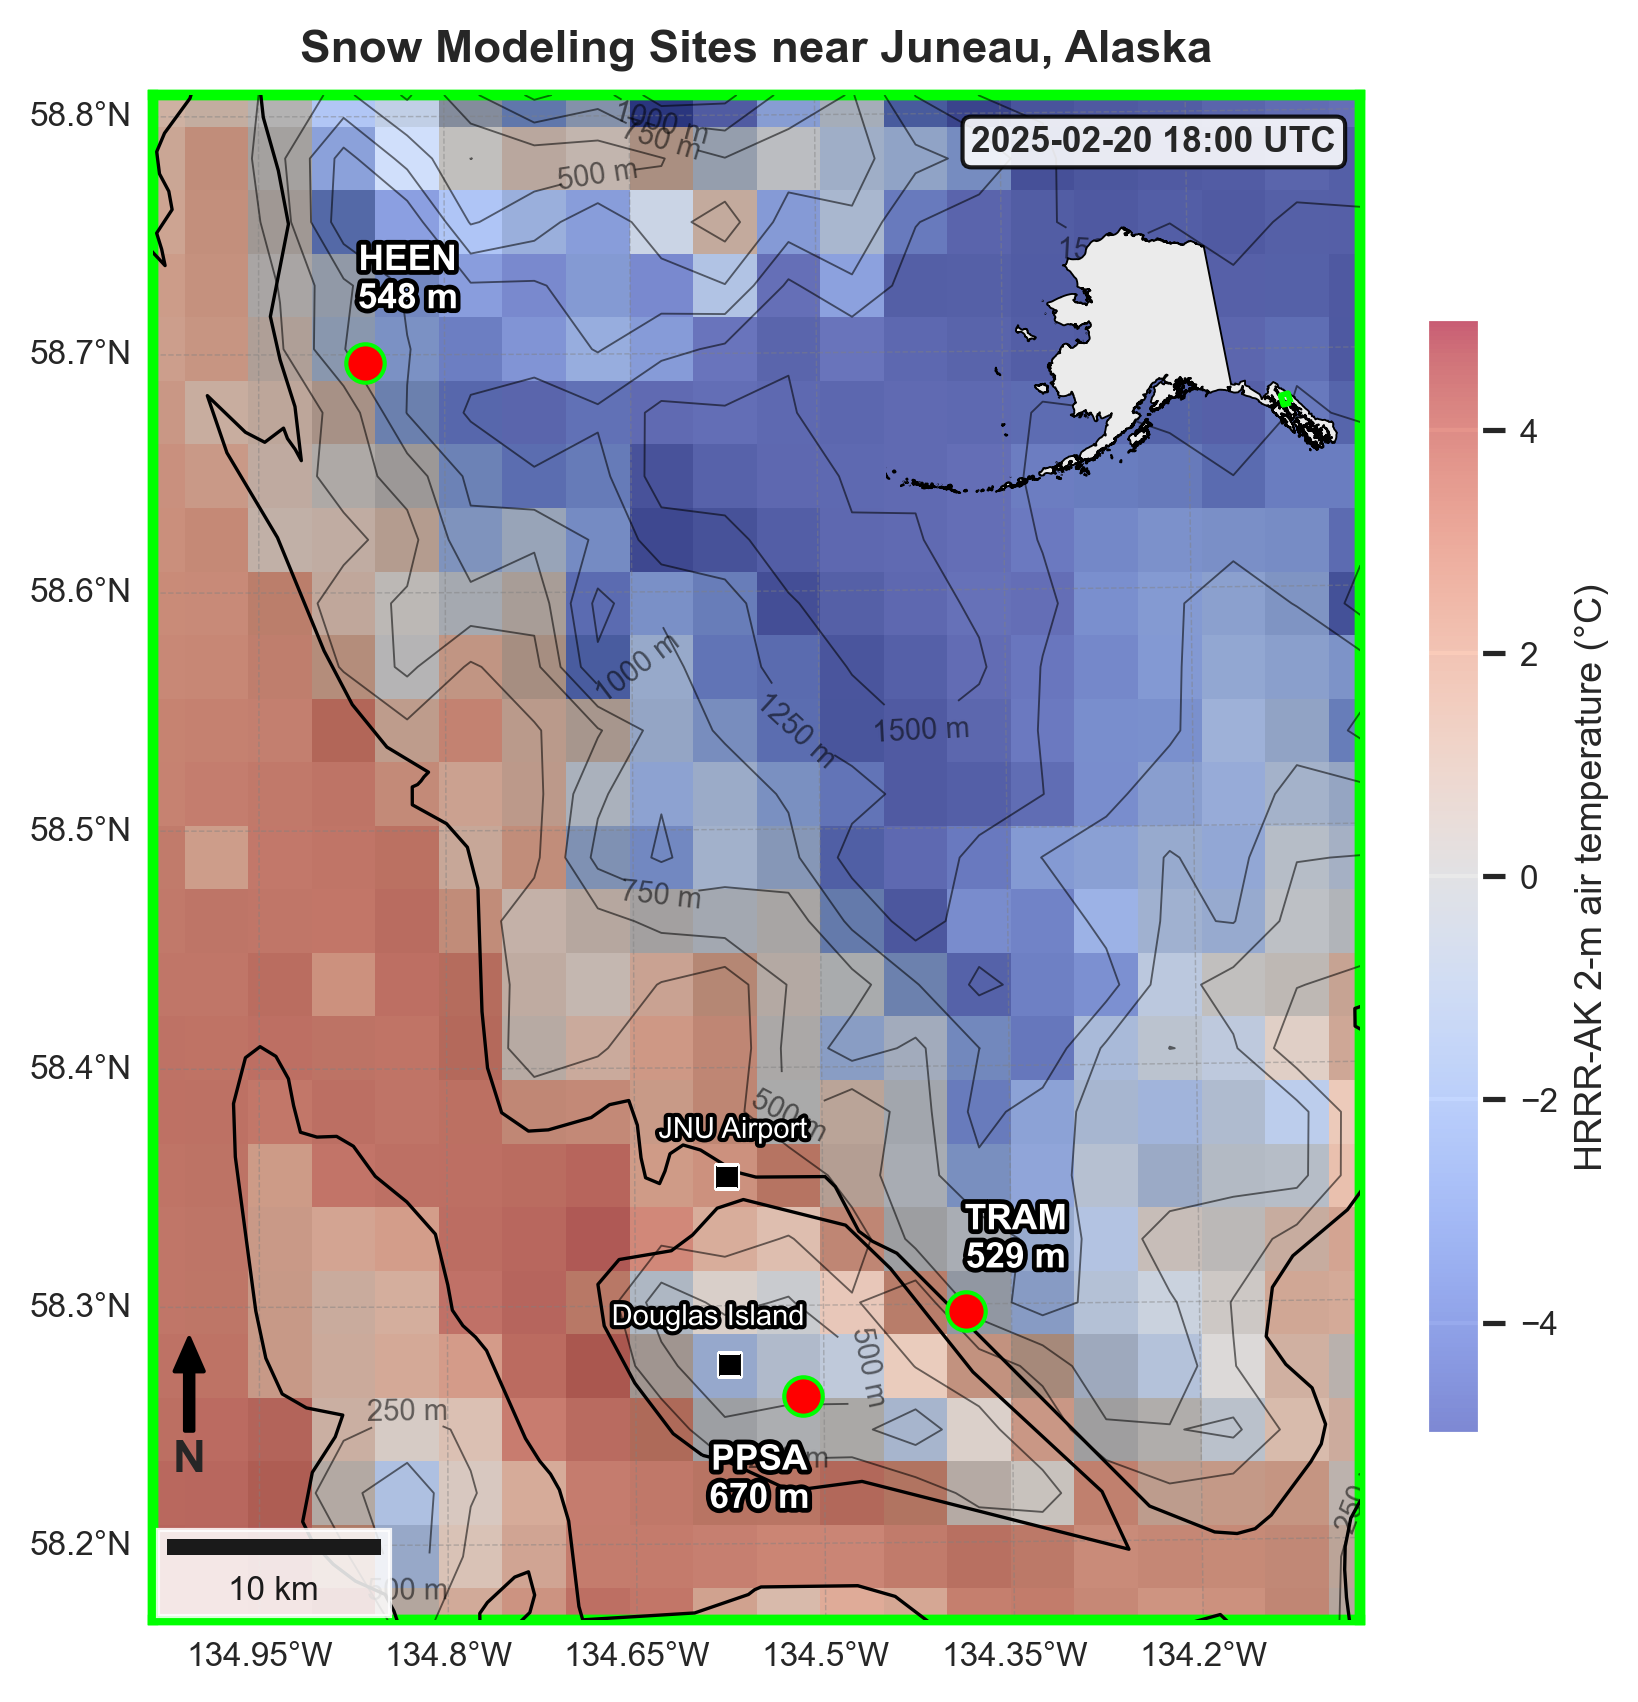

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point, box

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm


# =============================================================================
# USER SETTINGS
# =============================================================================

plot_time = pd.to_datetime("2025-02-20T18:00:00")

show_temperature = True      # True = overlay HRRR-AK TA; False = topo-only map
temp_min = -5
temp_max = 5

temp_norm = TwoSlopeNorm(
    vmin=temp_min,
    vcenter=0,
    vmax=temp_max
)

alaska_shp = '/hdd/snow_hydrology/shape_files/alaska_censusdotgov.shp'   # dropped it in here for now 

site_marker_size = 85
fontsize = 9

proj = ccrs.UTM(8)
pc = ccrs.PlateCarree()


# =============================================================================
# SITE INFORMATION
# =============================================================================

sites = {
    "PPSA": {"lat": 58.26200, "lon": -134.51700, "elev": 670},
    "TRAM": {"lat": 58.29710, "lon": -134.38600, "elev": 529},
    "HEEN": {"lat": 58.69652, "lon": -134.86448, "elev": 548},
}

gdf_sites = gpd.GeoDataFrame(
    {
        "site_id": list(sites.keys()),
        "elev_m": [sites[s]["elev"] for s in sites],
        "geometry": [Point(sites[s]["lon"], sites[s]["lat"]) for s in sites],
    },
    crs="EPSG:4326",
)


# =============================================================================
# DATA PREP
# =============================================================================

terrain = ds_utm["orog"].isel(time=0)

x = ds_utm["x"].values
y = ds_utm["y"].values
z = terrain.values

# Hillshade from HRRR-AK orography
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(
    z,
    vert_exag=1.5,
    dx=np.nanmedian(np.diff(x)),
    dy=np.nanmedian(np.diff(y)),
)

if show_temperature:
    temp = ds_utm["temp"].sel(time=plot_time, method="nearest") - 273.15
    actual_time = pd.to_datetime(temp["time"].values)
else:
    actual_time = None


# Domain in UTM
xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

domain_poly_utm = gpd.GeoDataFrame(
    geometry=[box(xmin, ymin, xmax, ymax)],
    crs="EPSG:32608",
).to_crs("EPSG:4326")

# =============================================================================
# FIGURE SETUP
# =============================================================================

fig = plt.figure(figsize=(7.2, 6.2), dpi=300)

ax = fig.add_axes([0.08, 0.10, 0.72, 0.82], projection=proj) 

# Move Alaska inset to upper-right instead of upper-left
ax_inset = fig.add_axes(
    [0.5, 0.66, 0.23, 0.23], # left, bottom, width, height
    projection=ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65),
    )
)

# Move colorbar closer to main map
# cax = fig.add_axes([0.805, 0.20, 0.025, 0.60])
cax = fig.add_axes([0.75, 0.20, 0.025, 0.60]) # trying to move it closer 


# =============================================================================
# MAIN MAP: HILLSHADE + OPTIONAL TEMPERATURE
# =============================================================================

ax.pcolormesh(
    x, y, hillshade,
    cmap="Greys",
    shading="auto",
    transform=proj,
    alpha=0.95,
    zorder=1,
)

if show_temperature:
    im = ax.pcolormesh(
        x, y, temp.values,
        cmap="coolwarm", # "RdBu_r" or coolwarm
        shading="auto",
        norm=temp_norm,
        transform=proj,
        alpha=0.62,
        zorder=2,
    )

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("HRRR-AK 2-m air temperature (°C)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)
else:
    cax.set_visible(False)


# =============================================================================
# TOPOGRAPHY CONTOURS
# =============================================================================

contours = ax.contour(
    x, y, z,
    levels=[250, 500, 750, 1000, 1250, 1500],
    colors="black",
    linewidths=0.45,
    alpha=0.55,
    transform=proj,
    zorder=3,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m",
)


# =============================================================================
# MAP FEATURES
# =============================================================================

ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAKES, linewidth=0.4, alpha=0.4, zorder=4)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.35, zorder=4)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.35,
    color="gray",
    alpha=0.45,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}


# =============================================================================
# SITE MARKERS
# =============================================================================

label_offsets = {
    "PPSA": (-0.035, -0.035),
    "TRAM": (0.040, 0.030),   # shifted up
    "HEEN": (0.035, 0.035),   # shifted up
}

for _, row in gdf_sites.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    site = row["site_id"]

    ax.scatter(
        lon, lat,
        s=site_marker_size,
        marker="o",
        facecolor="red",
        # edgecolor="black",
        edgecolor="lime",
        linewidth=1.0,
        transform=pc,
        zorder=10,
    )

    dx, dy = label_offsets.get(site, (0.02, 0.02))

    txt = ax.text(
        lon + dx,
        lat + dy,
        f"{site}\n{int(row['elev_m'])} m",
        fontsize=8.5,
        fontweight="bold",
        ha="center",
        va="center",
        color="white",
        transform=pc,
        zorder=11,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.3, foreground="black")
    ])


# =============================================================================
# LANDMARKS
# =============================================================================

landmarks = [
    {
        "name": "JNU Airport",
        "lon": -134.576,
        "lat": 58.354,
        "marker": "s",
        "dx": -0.055,     # shift label right
        "dy": 0.02,
        "ha": "left",
    },
    {
        "name": "Douglas Island",
        "lon": -134.575,
        "lat": 58.275,
        "marker": "s",
        "dx": 0.06,
        "dy": 0.02,
        "ha": "right",
    },
]

for lm in landmarks:
    ax.scatter(
        lm["lon"], lm["lat"],
        transform=pc,
        s=35,
        marker=lm["marker"],
        facecolor="black",
        edgecolor="white",
        linewidth=0.5,
        zorder=9,
    )

    txt = ax.text(
        lm["lon"] + lm["dx"],
        lm["lat"] + lm["dy"],
        lm["name"],
        fontsize=7,
        color="white",
        ha=lm["ha"],
        va="center",
        transform=pc,
        zorder=10,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground="black")
    ])


# =============================================================================
# SCALE BAR + NORTH ARROW
# =============================================================================

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.22,
    box_alpha=0.85,
    font_properties={"size": 8},
)

ax.add_artist(scalebar)

ax.annotate(
    "N",
    xy=(0.03, 0.185),      # arrow head, change the first number to move it left/right
    xytext=(0.03, 0.105),  # N label / arrow tail
    xycoords=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=2,
        headwidth=7,
        headlength=8,
    ),
    zorder=20,
)


# =============================================================================
# TIMESTAMP
# =============================================================================

if show_temperature:
    timestamp_str = actual_time.strftime("%Y-%m-%d %H:%M UTC")

    ax.text(
        0.98, 0.98,
        timestamp_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.88,
            boxstyle="round,pad=0.25",
        ),
        zorder=20,
    )


# =============================================================================
# ALASKA INSET
# =============================================================================

ak = gpd.read_file(alaska_shp).to_crs(ax_inset.projection.proj4_init)

ak.plot(
    ax=ax_inset,
    facecolor="0.92",
    edgecolor="black",
    linewidth=0.45,
    zorder=1,
)

domain_poly_ak = domain_poly_utm.to_crs(ax_inset.projection.proj4_init)
domain_poly_ak.boundary.plot(
    ax=ax_inset,
    edgecolor="lime",
    linewidth=1.4,
    zorder=5,
)

ax_inset.set_extent([-180, -128, 50, 73], crs=pc)
ax_inset.set_axis_off()

# ax_inset.text(
#     -0.5, 0.8,
#     "Alaska",
#     transform=ax_inset.transAxes,
#     ha="left",
#     va="top",
#     fontsize=8,
#     fontweight="bold",
# )

# =============================================================================
# LIME GREEN FRAME AROUND MAP
# =============================================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("lime")
    spine.set_linewidth(2.5)


# =============================================================================
# TITLE / EXPORT
# =============================================================================

ax.set_title(
    "Snow Modeling Sites near Juneau, Alaska",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

# =============================================================================
# EXPORT FIGURE
# =============================================================================

# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Use the DEM

In [1]:
import rioxarray
from rasterio.enums import Resampling

In [10]:
# File paths 
filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/large_juneau_domain/'
filename =  'dem_2m_UTM_clip_large_juneau_domain.tif'# now, this file should be in UTM coordinates (EPSG:32608)
raster_path = os.path.join(filepath, filename)

# open the DEM with rioxarray
dem = rioxarray.open_rasterio(raster_path, masked=True)
dem = dem.rio.write_crs("EPSG:32608")  # Set the CRS to UTM Zone 8N

dem.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]')

In [11]:
# =============================================================================
# RESAMPLE 2-m DEM TO COARSER RESOLUTION FOR CONTOURS
# =============================================================================

target_res = 20  # meters

# Make sure DEM is single-band
dem_2m = dem.squeeze(drop=True)

# Ensure CRS is set
dem_2m = dem_2m.rio.write_crs("EPSG:32608")

# Calculate scale factor from current resolution
xres, yres = dem_2m.rio.resolution()
xres = abs(xres)
yres = abs(yres)

scale_x = xres / target_res
scale_y = yres / target_res

new_width = int(dem_2m.rio.width * scale_x)
new_height = int(dem_2m.rio.height * scale_y)

dem_20m = dem_2m.rio.reproject(
    dem_2m.rio.crs,
    shape=(new_height, new_width),
    resampling=Resampling.average,
)

print("Original DEM resolution:", dem_2m.rio.resolution())
print("Resampled DEM resolution:", dem_20m.rio.resolution())
print("DEM shape:", dem_2m.shape, "→", dem_20m.shape)

Original DEM resolution: (2.0, -2.0)
Resampled DEM resolution: (19.99999999999998, -20.001092299290004)
DEM shape: (36622, 30170) → (3662, 3017)


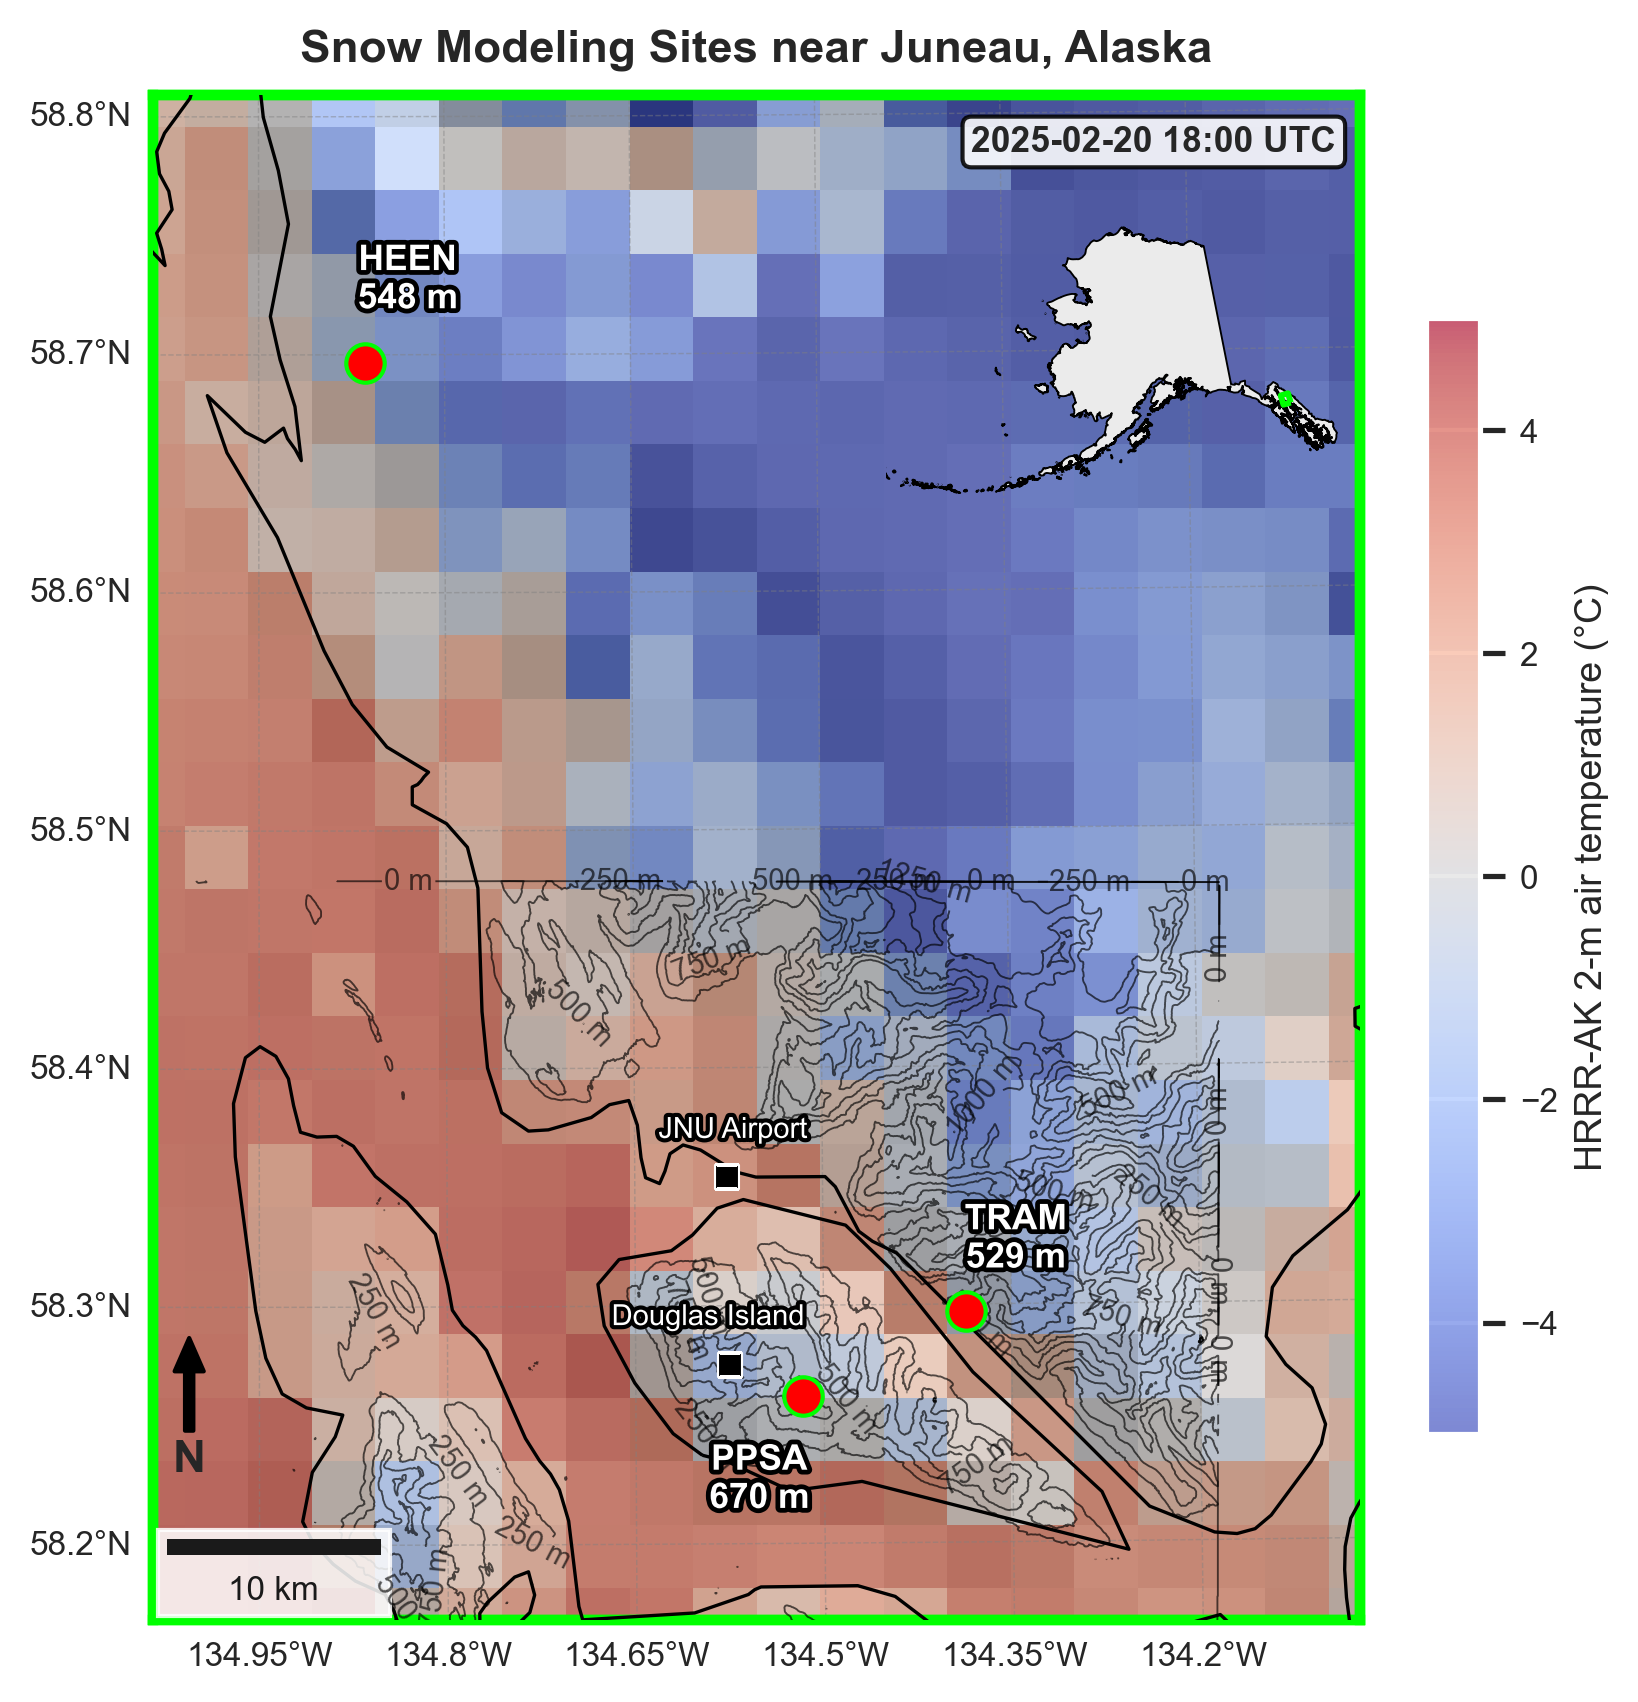

In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point, box

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm


# =============================================================================
# USER SETTINGS
# =============================================================================

plot_time = pd.to_datetime("2025-02-20T18:00:00")

show_temperature = True      # True = overlay HRRR-AK TA; False = topo-only map
temp_min = -5
temp_max = 5

temp_norm = TwoSlopeNorm(
    vmin=temp_min,
    vcenter=0,
    vmax=temp_max
)

alaska_shp = '/hdd/snow_hydrology/shape_files/alaska_censusdotgov.shp'   # dropped it in here for now 

site_marker_size = 85
fontsize = 9

proj = ccrs.UTM(8)
pc = ccrs.PlateCarree()


# =============================================================================
# SITE INFORMATION
# =============================================================================

sites = {
    "PPSA": {"lat": 58.26200, "lon": -134.51700, "elev": 670},
    "TRAM": {"lat": 58.29710, "lon": -134.38600, "elev": 529},
    "HEEN": {"lat": 58.69652, "lon": -134.86448, "elev": 548},
}

gdf_sites = gpd.GeoDataFrame(
    {
        "site_id": list(sites.keys()),
        "elev_m": [sites[s]["elev"] for s in sites],
        "geometry": [Point(sites[s]["lon"], sites[s]["lat"]) for s in sites],
    },
    crs="EPSG:4326",
)


# =============================================================================
# DATA PREP
# =============================================================================

terrain = ds_utm["orog"].isel(time=0)

x = ds_utm["x"].values
y = ds_utm["y"].values
z = terrain.values

# Hillshade from HRRR-AK orography
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(
    z,
    vert_exag=1.5,
    dx=np.nanmedian(np.diff(x)),
    dy=np.nanmedian(np.diff(y)),
)

if show_temperature:
    temp = ds_utm["temp"].sel(time=plot_time, method="nearest") - 273.15
    actual_time = pd.to_datetime(temp["time"].values)
else:
    actual_time = None


# Domain in UTM
xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

domain_poly_utm = gpd.GeoDataFrame(
    geometry=[box(xmin, ymin, xmax, ymax)],
    crs="EPSG:32608",
).to_crs("EPSG:4326")

# =============================================================================
# FIGURE SETUP
# =============================================================================

fig = plt.figure(figsize=(7.2, 6.2), dpi=300)

ax = fig.add_axes([0.08, 0.10, 0.72, 0.82], projection=proj) 

# Move Alaska inset to upper-right instead of upper-left
ax_inset = fig.add_axes(
    [0.5, 0.66, 0.23, 0.23], # left, bottom, width, height
    projection=ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65),
    )
)

# Move colorbar closer to main map
# cax = fig.add_axes([0.805, 0.20, 0.025, 0.60])
cax = fig.add_axes([0.75, 0.20, 0.025, 0.60]) # trying to move it closer 


# =============================================================================
# MAIN MAP: HILLSHADE + OPTIONAL TEMPERATURE
# =============================================================================

ax.pcolormesh(
    x, y, hillshade,
    cmap="Greys",
    shading="auto",
    transform=proj,
    alpha=0.95,
    zorder=1,
)

if show_temperature:
    im = ax.pcolormesh(
        x, y, temp.values,
        cmap="coolwarm", # "RdBu_r" or coolwarm
        shading="auto",
        norm=temp_norm,
        transform=proj,
        alpha=0.62,
        zorder=2,
    )

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("HRRR-AK 2-m air temperature (°C)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)
else:
    cax.set_visible(False)


# =============================================================================
# HIGH-RES DEM TOPOGRAPHY CONTOURS
# =============================================================================

dem_contour = dem_20m

dem_x = dem_contour["x"].values
dem_y = dem_contour["y"].values
dem_z = dem_contour.values

contour_levels = np.arange(0, 1800, 250) # 0, 1800, 500 for cleaner contours

contours = ax.contour(
    dem_x,
    dem_y,
    dem_z,
    levels=contour_levels,
    colors="black",
    linewidths=0.45,
    alpha=0.65,
    transform=proj,
    zorder=5,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m",
)


# =============================================================================
# MAP FEATURES
# =============================================================================

ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAKES, linewidth=0.4, alpha=0.4, zorder=4)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.35, zorder=4)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.35,
    color="gray",
    alpha=0.45,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}


# =============================================================================
# SITE MARKERS
# =============================================================================

label_offsets = {
    "PPSA": (-0.035, -0.035),
    "TRAM": (0.040, 0.030),   # shifted up
    "HEEN": (0.035, 0.035),   # shifted up
}

for _, row in gdf_sites.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    site = row["site_id"]

    ax.scatter(
        lon, lat,
        s=site_marker_size,
        marker="o",
        facecolor="red",
        # edgecolor="black",
        edgecolor="lime",
        linewidth=1.0,
        transform=pc,
        zorder=10,
    )

    dx, dy = label_offsets.get(site, (0.02, 0.02))

    txt = ax.text(
        lon + dx,
        lat + dy,
        f"{site}\n{int(row['elev_m'])} m",
        fontsize=8.5,
        fontweight="bold",
        ha="center",
        va="center",
        color="white",
        transform=pc,
        zorder=11,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.3, foreground="black")
    ])


# =============================================================================
# LANDMARKS
# =============================================================================

landmarks = [
    {
        "name": "JNU Airport",
        "lon": -134.576,
        "lat": 58.354,
        "marker": "s",
        "dx": -0.055,     # shift label right
        "dy": 0.02,
        "ha": "left",
    },
    {
        "name": "Douglas Island",
        "lon": -134.575,
        "lat": 58.275,
        "marker": "s",
        "dx": 0.06,
        "dy": 0.02,
        "ha": "right",
    },
]

for lm in landmarks:
    ax.scatter(
        lm["lon"], lm["lat"],
        transform=pc,
        s=35,
        marker=lm["marker"],
        facecolor="black",
        edgecolor="white",
        linewidth=0.5,
        zorder=9,
    )

    txt = ax.text(
        lm["lon"] + lm["dx"],
        lm["lat"] + lm["dy"],
        lm["name"],
        fontsize=7,
        color="white",
        ha=lm["ha"],
        va="center",
        transform=pc,
        zorder=10,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground="black")
    ])


# =============================================================================
# SCALE BAR + NORTH ARROW
# =============================================================================

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.22,
    box_alpha=0.85,
    font_properties={"size": 8},
)

ax.add_artist(scalebar)

ax.annotate(
    "N",
    xy=(0.03, 0.185),      # arrow head, change the first number to move it left/right
    xytext=(0.03, 0.105),  # N label / arrow tail
    xycoords=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=2,
        headwidth=7,
        headlength=8,
    ),
    zorder=20,
)


# =============================================================================
# TIMESTAMP
# =============================================================================

if show_temperature:
    timestamp_str = actual_time.strftime("%Y-%m-%d %H:%M UTC")

    ax.text(
        0.98, 0.98,
        timestamp_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.88,
            boxstyle="round,pad=0.25",
        ),
        zorder=20,
    )


# =============================================================================
# ALASKA INSET
# =============================================================================

ak = gpd.read_file(alaska_shp).to_crs(ax_inset.projection.proj4_init)

ak.plot(
    ax=ax_inset,
    facecolor="0.92",
    edgecolor="black",
    linewidth=0.45,
    zorder=1,
)

domain_poly_ak = domain_poly_utm.to_crs(ax_inset.projection.proj4_init)
domain_poly_ak.boundary.plot(
    ax=ax_inset,
    edgecolor="lime",
    linewidth=1.4,
    zorder=5,
)

ax_inset.set_extent([-180, -128, 50, 73], crs=pc)
ax_inset.set_axis_off()

# ax_inset.text(
#     -0.5, 0.8,
#     "Alaska",
#     transform=ax_inset.transAxes,
#     ha="left",
#     va="top",
#     fontsize=8,
#     fontweight="bold",
# )

# =============================================================================
# LIME GREEN FRAME AROUND MAP
# =============================================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("lime")
    spine.set_linewidth(2.5)


# =============================================================================
# TITLE / EXPORT
# =============================================================================

ax.set_title(
    "Snow Modeling Sites near Juneau, Alaska",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

# plt.savefig(
#     "figure_site_map_juneau_topography_temperature.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

# plt.savefig(
#     "figure_site_map_juneau_topography_temperature.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

That will be great once we merge the entire dem together...